In [33]:
import polars as pl
import pandas as pd
import numpy as np
import altair as alt
import pyarrow
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from func.UsefulFunctions import *
import geopandas as gpd

This jupyter notebook inspects the contents of the artists (that is individual performers/creatives) to gain an understanding of their statistics. The sou

In [34]:

artistDF = pl.read_parquet("/home/aja25/Documents/fromCluster/personMusicBrainzData.parquet")
#De-duplicate the data
artistDF = artistDF.unique()

#How many unique artists are there now. This data is now based off of the number of unique

num_of_ids = artistDF.select(
    pl.col("id")
).unique().count().item(0,0)
print(f"There are {num_of_ids} unique IDs in the dataset (that is a snapshot from 18/07/2026).")

There are 1574608 unique IDs in the dataset (that is a snapshot from 18/07/2026).


In [35]:
#How many people do not have a name in this dataset?
num_people_with_no_names = artistDF.select(
    pl.col("name"),
    pl.col("id")
).unique().null_count()
print(num_people_with_no_names)
print(f"There are {num_people_with_no_names.item(0,0)} entities with no name, and {num_people_with_no_names.item(0,1)} entities with no ids.")

shape: (1, 2)
┌──────┬─────┐
│ name ┆ id  │
│ ---  ┆ --- │
│ u32  ┆ u32 │
╞══════╪═════╡
│ 0    ┆ 0   │
└──────┴─────┘
There are 0 entities with no name, and 0 entities with no ids.


In [36]:
#check if there are any duplicates in ids
ids = artistDF.select(
    pl.col("id")
).is_duplicated()
print(ids.value_counts())

print("Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication ")

shape: (1, 2)
┌───────┬─────────┐
│       ┆ count   │
│ ---   ┆ ---     │
│ bool  ┆ u32     │
╞═══════╪═════════╡
│ false ┆ 1574608 │
└───────┴─────────┘
Based off of the lack of trues in the is_duplicated function. All rows are unique after the deduplication 


In [37]:
#Do a count for the countries for the dataset.
countryCount = artistDF.select(pl.col("country").value_counts(sort=True)).unnest("country")
print(countryCount)

shape: (252, 2)
┌─────────┬────────┐
│ country ┆ count  │
│ ---     ┆ ---    │
│ str     ┆ u32    │
╞═════════╪════════╡
│ null    ┆ 655691 │
│ US      ┆ 220745 │
│ GB      ┆ 81004  │
│ JP      ┆ 75389  │
│ DE      ┆ 71965  │
│ …       ┆ …      │
│ BV      ┆ 1      │
│ NU      ┆ 1      │
│ AN      ┆ 1      │
│ SH      ┆ 1      │
│ HM      ┆ 1      │
└─────────┴────────┘


The most common country for individual performers (outside of null which trumps it) is US followed by GB and Japan.

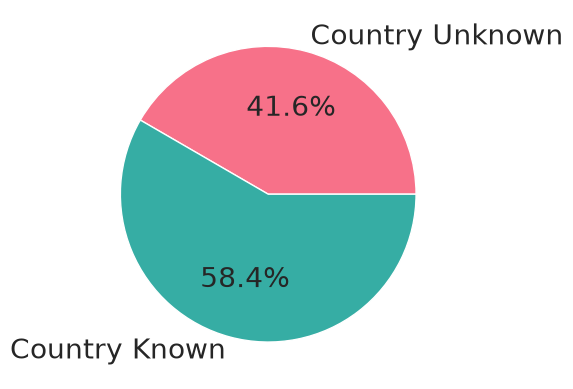

In [38]:
#Make a pie chart for people who have a country and does who don't
noCountry = (artistDF
             .filter(
    pl.col("country").is_null(),
    ).select(pl.col("id")).drop_nulls().unique())
hasCountry = (artistDF
              .filter(
    pl.col("country").is_not_null(),
).select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=20)
makePieChart(["Country Unknown", "Country Known"], [len(noCountry), len(hasCountry)],
             "Country Known vs Unknown on MusicBrainz for Groups", "husl")

,ISO_A2,geometry
0,ZW,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,ZM,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."


country          str
count         uint32
log_count    float64
dtype: object


,ISO_A2,count,log_count
0,US,220745,12.304763
1,GB,81004,11.302254
2,JP,75389,11.230417
3,DE,71965,11.183935
4,FR,45674,10.729284
...,...,...,...
246,BV,1,0.000000
247,NU,1,0.000000
248,AN,1,0.000000
249,SH,1,0.000000


,ISO_A2,geometry,count,log_count
0,ZW,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344...",255.0,5.541264
1,ZM,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643...",200.0,5.298317
2,YE,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16...",67.0,4.204693
3,VN,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ...",1274.0,7.149917
4,VE,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9...",1004.0,6.911747


<Axes: >

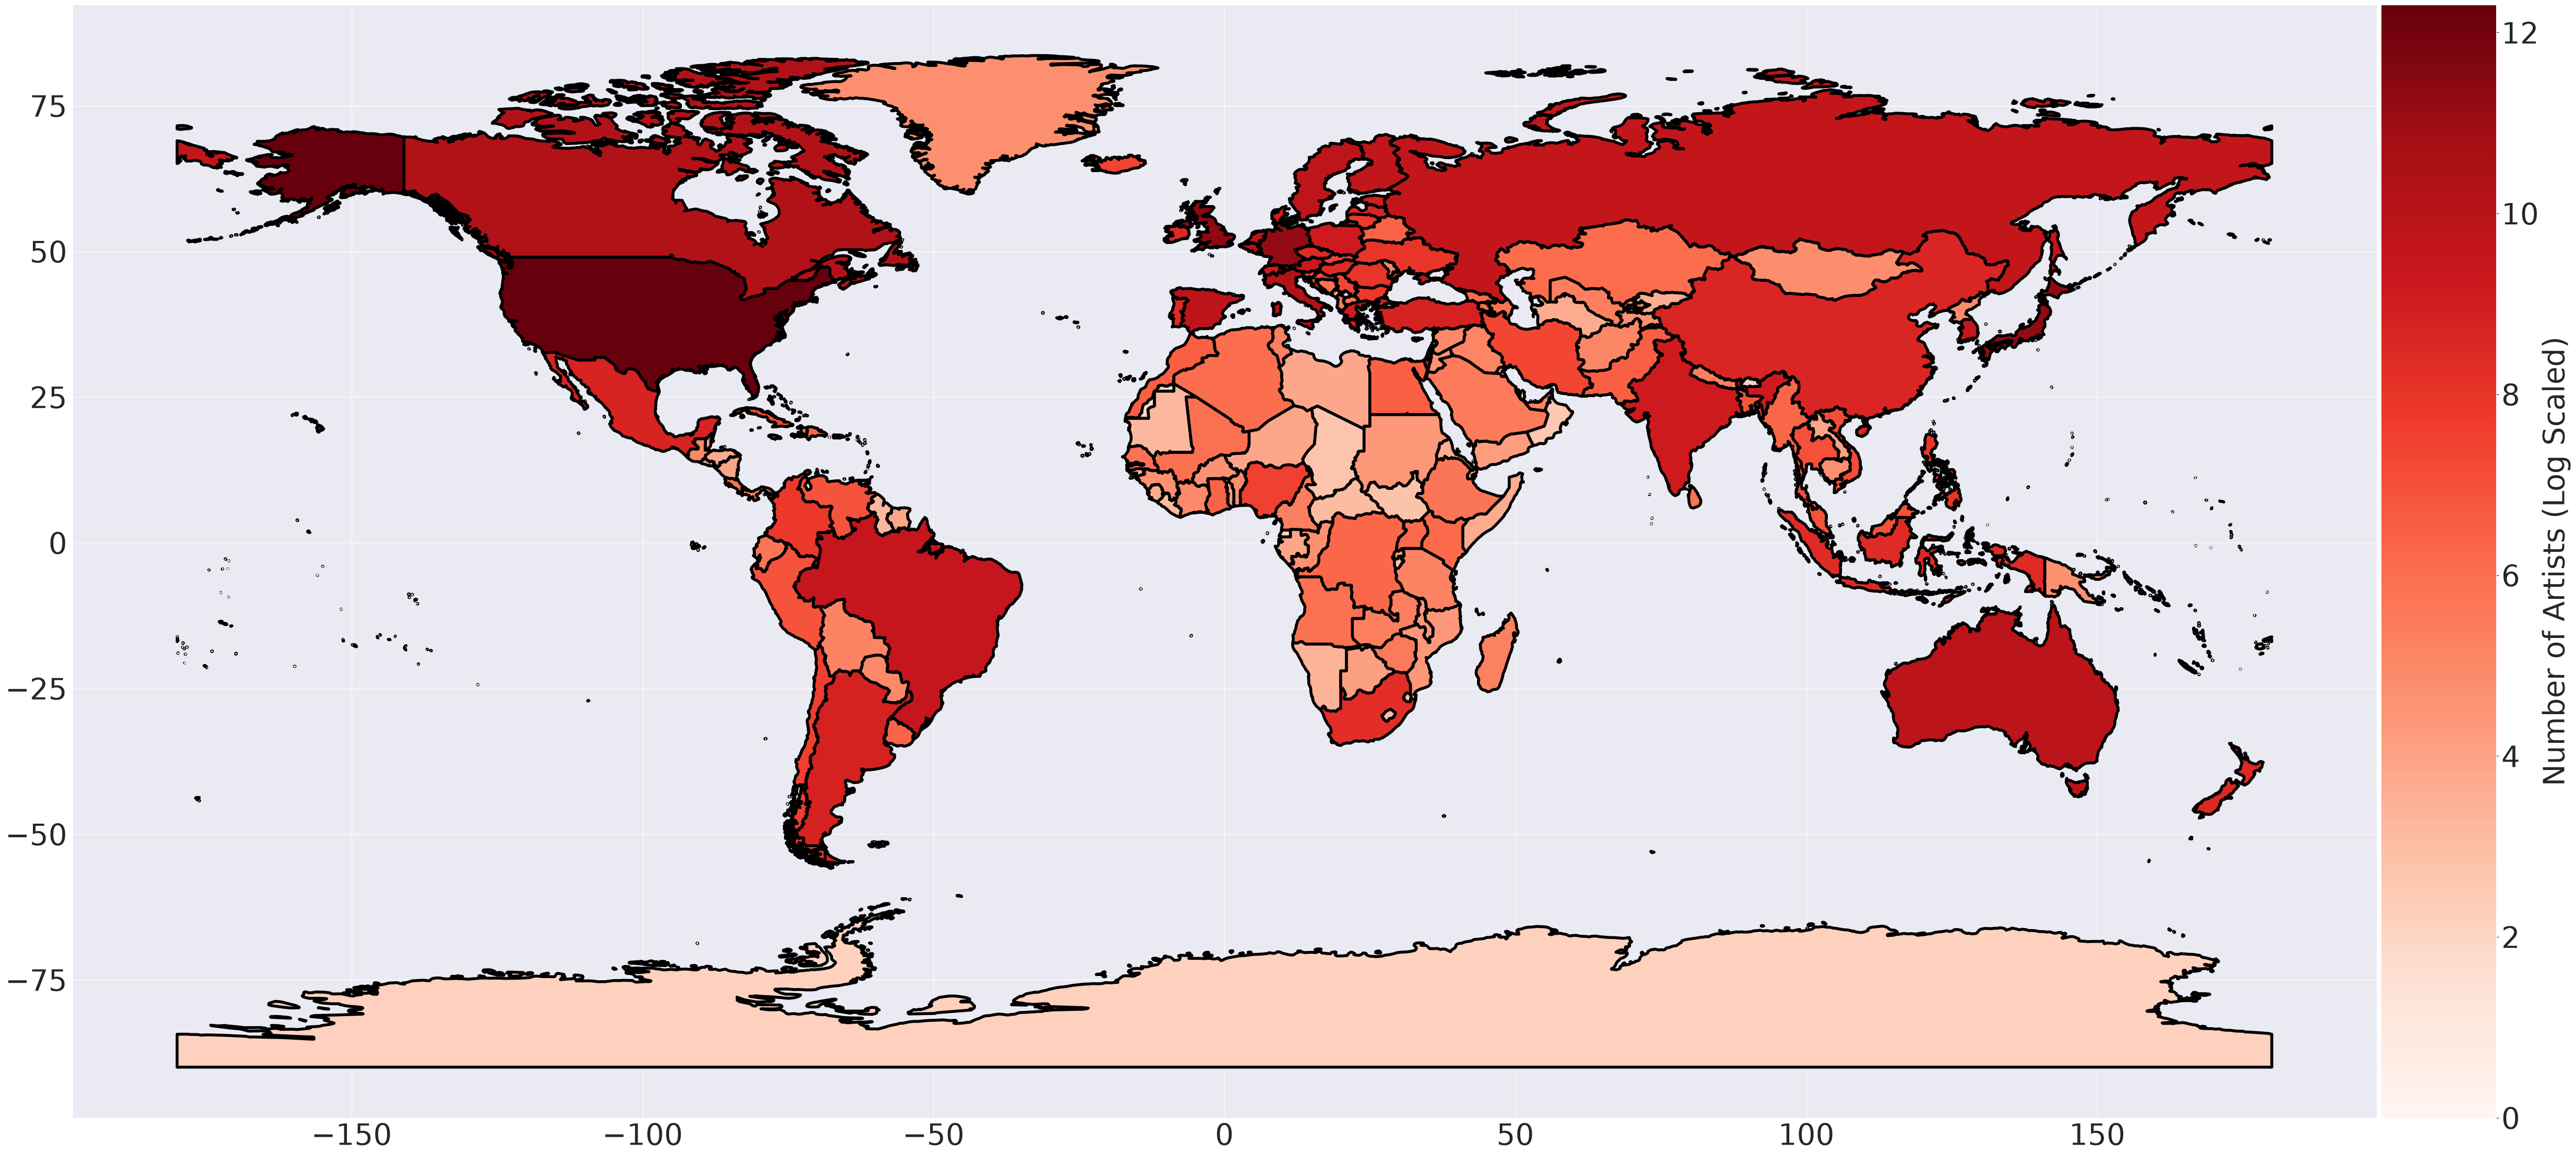

In [39]:
#Create a heatmap for the countries of artists on MusicbRAINZ

worldMap = gpd.read_file("./mapData/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp")

worldMap = worldMap[['ISO_A2','geometry']]
display(worldMap.head())
countryCountPandas = countryCount.drop_nulls().to_pandas()
countryCountPandas["log_count"] = np.log(countryCountPandas["count"])
print(countryCountPandas.dtypes)
countryCountPandas = countryCountPandas.rename(columns={"country":"ISO_A2"})
display(countryCountPandas)
preppedCountryData = worldMap.merge(countryCountPandas, on='ISO_A2', how='left')
display(preppedCountryData.head())

plt.rc('font', size=40)
fig, axMap = plt.subplots(figsize=(60,60))

divider = make_axes_locatable(axMap)
cax = divider.append_axes("right", size="5%", pad=0.05)
cax.tick_params(labelsize=40)
preppedCountryData.plot(column="log_count",
                        cmap="Reds",
                        edgecolor="black",
                        linewidth=4,
                        ax = axMap,
                        cax = cax,
                        legend=True,
                        legend_kwds={"label":"Number of Artists (Log Scaled)"},)


shape: (6, 2)
┌────────────────┬────────┐
│ gender         ┆ count  │
│ ---            ┆ ---    │
│ str            ┆ u32    │
╞════════════════╪════════╡
│ Male           ┆ 947583 │
│ null           ┆ 345419 │
│ Female         ┆ 277599 │
│ Non-binary     ┆ 2344   │
│ Other          ┆ 1244   │
│ Not applicable ┆ 419    │
└────────────────┴────────┘


alt.Chart(...)

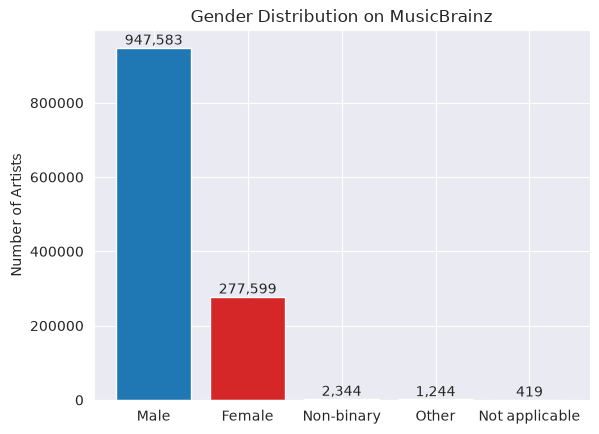

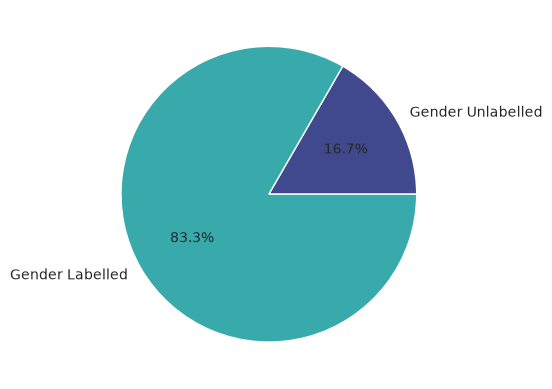

In [40]:
#What is the gender split like for the entities
genderCount = artistDF.select(pl.col("gender").value_counts(sort=True)).unnest("gender")
genderCountPercent = artistDF.select(pl.col("gender").value_counts(sort=True, normalize=True, name="Fraction")).unnest("gender")
print(genderCount)
genderChart = (
    alt.Chart(genderCount).mark_bar().encode(
    y="count",
    x="gender",
    )
    .properties(width=500, title="Gender Distribution of Music Brainz")
)
genderChart.encoding.x.title = "Genders"
genderChart.encoding.y.title = "Counts"
genderChart.show()

genderCountNoNulls = genderCount.drop_nulls()
plt.rc('font', size=10)
makeBarChart(genderCountNoNulls["gender"], genderCountNoNulls["count"], "Gender Distribution on MusicBrainz", "Number of Artists")

makePieChart(["Gender Unlabelled", "Gender Labelled"], [len (genderCount) - len(genderCountNoNulls), len(genderCountNoNulls)],  "", "mako")


In [41]:
print(genderCountPercent)

shape: (6, 2)
┌────────────────┬──────────┐
│ gender         ┆ Fraction │
│ ---            ┆ ---      │
│ str            ┆ f64      │
╞════════════════╪══════════╡
│ Male           ┆ 0.60179  │
│ null           ┆ 0.219368 │
│ Female         ┆ 0.176297 │
│ Non-binary     ┆ 0.001489 │
│ Other          ┆ 0.00079  │
│ Not applicable ┆ 0.000266 │
└────────────────┴──────────┘


Overwhelmingly, the dataset skews towards men with ~60.2% of the dataset being men. More individuals do not have their gender attributed to them than female individuals.

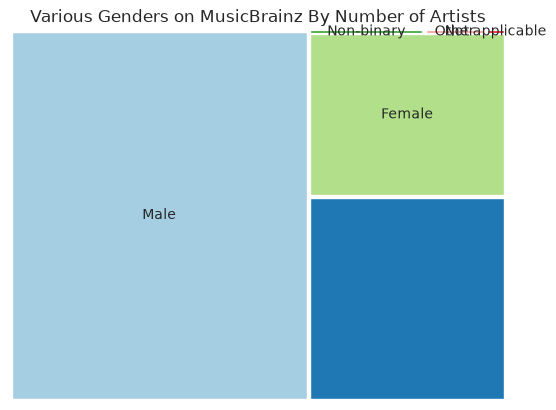

In [42]:
#Make a treemap of the genders
genderCountNoNulls = genderCount.drop_nulls()
makeTreeMap(genderCount["gender"], genderCount["count"], "Paired", "Various Genders on MusicBrainz By Number of Artists", pad=1 )

In [43]:
artistDFPandas = artistDF.to_pandas(use_pyarrow_extension_array=True)
artistDFPandas['genreList'] = artistDFPandas['genres'].map(prettifyGenres)
display(artistDFPandas.head(5))
display(artistDFPandas[artistDFPandas.name == "Madonna"])
artistDF = pl.from_pandas(artistDFPandas)
madonna = artistDF.filter(pl.col("name") == "Madonna")
display(madonna.head(5))


,id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
0,f5898d5e-7953-424a-82bc-a3df5e8d67d6,Ko Win Maung,Person,<NA>,MM,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
1,8cfbda63-5b2a-41b3-8893-1cd682daea9c,Robbie Rushton,Person,Male,GB,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
2,98ae4bc0-3d47-4a9e-9f22-ddc6c8271d18,The Eight Wonder,Person,<NA>,GB,[],[],[],"{'end': None, 'begin': '2010', 'ended': False}",[]
3,9fd85167-2da5-4339-944c-6efeb31e77ee,Renato Milagres,Person,<NA>,<NA>,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
4,cea12585-f756-42d9-b90e-9d7282e3d65b,David Mason,Person,Male,US,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]


,id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
429367,3fd13140-6857-489a-9e53-a4e112b8354b,Madonna,Person,Female,LB,[],[],[],"{'end': None, 'begin': None, 'ended': False}",[]
430260,79239441-bfd5-4981-a70c-55c3f15c1287,Madonna,Person,Female,US,[{'id': '930ef127-3653-4677-9b95-ecc90c7c1a14'...,['000000010782262X'],['00125053706' '00128246872' '00211854787'],"{'end': None, 'begin': '1958-08-16', 'ended': ...","[art pop, bubblegum pop, club, contemporary r&..."


id,name,type,gender,country,genres,isnis,ipis,life-span,genreList
str,str,str,str,str,list[struct[4]],list[str],list[str],struct[3],list[str]
"""3fd13140-6857-489a-9e53-a4e112…","""Madonna""","""Person""","""Female""","""LB""",[],[],[],"{null,null,false}",[]
"""79239441-bfd5-4981-a70c-55c3f1…","""Madonna""","""Person""","""Female""","""US""","[{""930ef127-3653-4677-9b95-ecc90c7c1a14"",7,"""",""art pop""}, {""6fd83b83-9b63-47fa-a208-5f9e762f40ab"",1,"""",""bubblegum pop""}, … {""45eb1d9c-588c-4dc8-9394-a14b7c8f02bc"",1,"""",""trip hop""}]","[""000000010782262X""]","[""00125053706"", ""00128246872"", ""00211854787""]","{null,""1958-08-16"",false}","[""art pop"", ""bubblegum pop"", … ""trip hop""]"


In [44]:
#Save the artist parquet now for network use
artistDF.write_parquet("./Data/Network_personMBData.parquet")

In [45]:
#Get the most common genre

idGenre = artistDF.select(
    pl.col("id"),
    pl.col("name"),
    pl.col("gender"),
    pl.col("genreList").alias("Genre"),
)

idGenre = idGenre.explode("Genre", empty_as_null=True, keep_nulls=True)
idGenre = idGenre.unique()
number_of_genres = idGenre.select(
    pl.col("Genre").value_counts(sort=True)
).unnest("Genre")
print(number_of_genres)


shape: (1_561, 2)
┌────────────────┬─────────┐
│ Genre          ┆ count   │
│ ---            ┆ ---     │
│ str            ┆ u32     │
╞════════════════╪═════════╡
│ null           ┆ 1481063 │
│ hip hop        ┆ 16678   │
│ jazz           ┆ 12343   │
│ pop            ┆ 8408    │
│ electronic     ┆ 6811    │
│ …              ┆ …       │
│ gaita zuliana  ┆ 1       │
│ surf punk      ┆ 1       │
│ andean new age ┆ 1       │
│ birdsong       ┆ 1       │
│ philly club    ┆ 1       │
└────────────────┴─────────┘


Most individuals do not have a genre attached to them based off of MusicBrainz's list of genres but the most popular genre is hip hop followed by Jazz music.

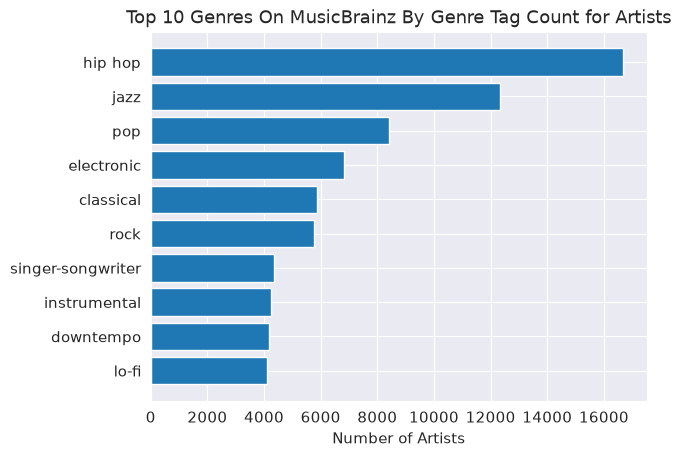

In [57]:
#Top genres
top10Genres = number_of_genres.drop_nulls()[0:10]
plt.rc('font', size=11)
horizontalBarChart(top10Genres["Genre"], top10Genres["count"], "Top 10 Genres On MusicBrainz By Genre Tag Count for Artists", "Number of Artists")

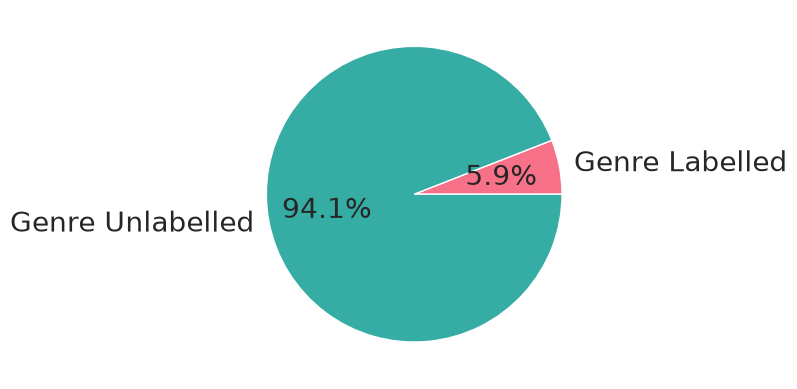

In [46]:
#Make a pie chart for people who have at least one genre and those who dont
noGenre = (idGenre
           .filter(
    pl.col("Genre").is_null(),
    ).select(pl.col("id")).drop_nulls().unique())
hasGenre = (idGenre
              .filter(
    pl.col("Genre").is_not_null(),
).select(pl.col("id")).drop_nulls().unique())
plt.rc('font', size=20)
makePieChart(["Genre Labelled", "Genre Unlabelled"], [len(hasGenre), len(noGenre)],
             "Country Known vs Unknown on MusicBrainz for Groups", "husl")

In [49]:
hasGenre

id
str
"""0b0c25f4-f31c-46a5-a4fb-ccbf53…"
"""c6e01a16-2e6e-4ed9-b6d2-18d878…"
"""573635e0-30ce-4e42-b8e4-64c385…"
"""31b1e5eb-4f0b-4a4b-801e-446532…"
"""33559088-9899-4889-a3ac-c57503…"
…
"""fa4d867b-6f54-4d7f-832a-bb25aa…"
"""01f2fca9-bce8-4a55-b88b-2f2838…"
"""d3aaf2cd-8c74-4aaa-9689-79417d…"


In [100]:
#Look for the gender and genre split using group by.
idGenre.group_by(["gender", 'Genre']).agg(pl.col('id').count())

gender,Genre,id
str,str,u32
null,"""underground hip hop""",70
null,"""neue deutsche todeskunst""",1
"""Female""","""chicago drill""",1
"""Male""","""singer-songwriter""",2720
"""Other""","""acid house""",1
…,…,…
"""Male""","""dariacore""",1
"""Other""","""indie pop""",12
null,"""breakbeat""",49


In [101]:
#Most common gender-country pair.
artistDF.group_by(["gender","country"]).agg(pl.col('id').count())

gender,country,id
str,str,u32
"""Female""","""UM""",1
"""Male""","""GE""",272
"""Male""","""CU""",1227
null,"""MM""",49
"""Female""","""SE""",3362
…,…,…
"""Male""","""SG""",379
"""Female""","""NR""",1
"""Male""","""NG""",1567
